In [1]:
# The following lines enable automatic reloading of modules in an IPython/Jupyter environment.
# They work exactly like the commented lines below, but avoid errors when not running in such an environment.
# %load_ext autoreload
# %autoreload 2

try:
    get_ipython().run_line_magic("load_ext", "autoreload")
    get_ipython().run_line_magic("autoreload", "2")
except (NameError, AttributeError):
    pass


In [2]:
# Initializing answer variable
answer = {}


In [3]:
# Some libs that we will use
import torch
import random
import numpy as np
import json_tricks
import lovely_tensors as lt
from pprint import pprint

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

lt.monkey_patch()

import sys
root_path = '../../../..'
sys.path.append(root_path)

import dotenv
dotenv.load_dotenv(dotenv.find_dotenv(root_path + '/.env'))

import src
from src import utils


/usr/local/lib/python3.11/site-packages/mlflow/models/utils.py:50: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  from scipy.sparse import csc_matrix, csr_matrix


# Autoencoder on MNIST

In the previous chapter, we assembled the common training pieces for a classifier: dataset, model, loss dictionary, optimizer, scheduler, dataloaders, MLflow logger, and the shared training loop.

In this task, we will reuse that infrastructure for a different goal. Instead of predicting a digit label, an autoencoder receives an image, compresses it into an embedding, and reconstructs the same image from that embedding.

# Task 0: Prepare the Environment

## Goal

Set all random seeds with `src.utils.seed.seed_all(0)`. Reproducibility matters here because the reconstruction examples and training curves are easier to compare when initialization and dataloader shuffling are deterministic.

## Implementation Details

Write the seed call in the cell below. The expected student code should be placed after `## YOUR CODE HERE`.

In [4]:
## YOUR CODE HERE
src.utils.seed.seed_all(0)

seed_check = {
    'python.random': [random.random() for _ in range(4)],
    'numpy.random.rand': np.random.rand(2, 3),
    'torch.rand': torch.rand(2, 3),
    'torch.backends.cudnn.deterministic': torch.backends.cudnn.deterministic,
}
answer['seed_check'] = seed_check
pprint(seed_check)


{'numpy.random.rand': array([[0.5488135 , 0.71518937, 0.60276338],
       [0.54488318, 0.4236548 , 0.64589411]]),
 'python.random': [0.8444218515250481,
                   0.7579544029403025,
                   0.420571580830845,
                   0.25891675029296335],
 'torch.backends.cudnn.deterministic': True,
 'torch.rand': tensor[2, 3] n=6 x∈[0.088, 0.768] μ=0.404 σ=0.275 [[0.496, 0.768, 0.088], [0.132, 0.307, 0.634]]}


# Task 1: Reuse the MNIST Dataset

## Goal

Use the same `MNISTSimpleDataset` class from the shallow feedforward chapter.

## What To Create

Create two datasets:
- `MNIST_train = src.datasets.mnist_simple.MNISTSimpleDataset(train=True)`;
- `MNIST_valid = src.datasets.mnist_simple.MNISTSimpleDataset(train=False)`.

The dataset returns dictionaries with:
- `image`: a `float32` tensor shaped `[28, 28]`, scaled to `[-1, 1]`;
- `label`: a `long` tensor containing the digit class.

The autoencoder will use only the `image` field for training. Labels stay in the batch because we are reusing the dataset unchanged.

In [5]:
MNIST_train = src.datasets.mnist_simple.MNISTSimpleDataset(train=True)
MNIST_valid = src.datasets.mnist_simple.MNISTSimpleDataset(train=False)

## YOUR CODE HERE


In [6]:
train_sample = MNIST_train[0]
valid_sample = MNIST_valid[0]

X_train = train_sample['image']
X_valid = valid_sample['image']
y_train = train_sample['label']
y_valid = valid_sample['label']

print('X_train dtype:', X_train.dtype)
print('X_train shape:', X_train.shape)
print('y_train dtype:', y_train.dtype)
print('y_train shape:', y_train.shape)

answer['X_train.dtype'] = str(X_train.dtype)
answer['X_valid.dtype'] = str(X_valid.dtype)
answer['y_train.dtype'] = str(y_train.dtype)
answer['y_valid.dtype'] = str(y_valid.dtype)
answer['X_train.shape'] = list(X_train.shape)
answer['X_valid.shape'] = list(X_valid.shape)
answer['y_train.shape'] = list(y_train.shape)
answer['y_valid.shape'] = list(y_valid.shape)
answer['X_train.mean'] = float(X_train.mean())
answer['X_valid.mean'] = float(X_valid.mean())


X_train dtype: torch.float32
X_train shape: torch.Size([28, 28])
y_train dtype: torch.int64
y_train shape: torch.Size([])


Let us look at one image. The autoencoder will try to reconstruct images like this one.

In [7]:
%matplotlib inline

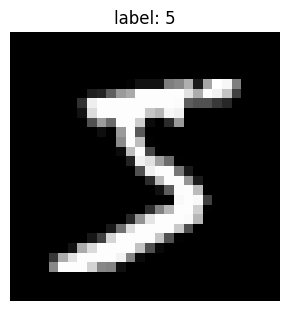

In [8]:
fig, ax = plt.subplots(figsize=(3, 3), constrained_layout=True)
ax.imshow(X_train, cmap='gray')
ax.set_title(f'label: {int(y_train)}')
ax.axis('off')
plt.show()


# Batch Updating Protocol

We will reuse the same batch protocol as the classifier task.

The training loop wraps a dataloader batch into:

```python
batch = {'data': original_batch}
```

For this autoencoder:
- the model reads `batch['data']['image']`;
- the model writes the reconstructed image to `batch['signals']['reconstruction']`;
- the MAE loss compares `batch['signals']['reconstruction']` with `batch['data']['image']`.

There is no accuracy metric in this task because reconstruction is not a classification problem.

# Task 2: Build the Autoencoder Class

## Goal

Edit [src/models/feedforward/autoencoder.py](../../../../src/models/feedforward/autoencoder.py) and implement the `Autoencoder` class.

## Architecture

The autoencoder must have a two-layer fully connected encoder and a two-layer fully connected decoder.

Use the channel list `[28 * 28, 256, 128]`:
- the encoder maps `784 -> 256 -> 128`;
- the embedding size is therefore `128`;
- the decoder mirrors the encoder and maps `128 -> 256 -> 784`.

Use the supplied `activation` class between the two linear layers in each direction. Do not put an activation after the final decoder layer, because the reconstruction should be free to match values in the dataset scale.

## Batch Protocol

Implement:
- `__init__`: create `self.encoder` and `self.decoder` as `torch.nn.Sequential` modules;
- `__forward_kernel`: flatten an image batch from `[batch, 28, 28]` to `[batch, 784]`, run encoder and decoder, then reshape the result back to the original image shape;
- `forward`: read `batch['data']['image']`, call `__forward_kernel`, and store the result in `batch['signals']['reconstruction']`.

The placeholders in `autoencoder.py` must remain the only places where student implementation code is expected.

In [9]:
autoencoder = src.models.feedforward.autoencoder.Autoencoder(
    [28 * 28, 256, 128],
    activation=torch.nn.LeakyReLU,
)

utils.deterministic_init(autoencoder)

check_batch = {
    'data': {
        'image': torch.randn(10, 28, 28),
        'label': torch.randint(low=0, high=10, size=(10,)),
    }
}

with torch.no_grad():
    autoencoder(check_batch)

print('input:', check_batch['data']['image'].shape)
print('reconstruction:', check_batch['signals']['reconstruction'].shape)
pprint(check_batch)

answer['check_batch'] = check_batch


input: torch.Size([10, 28, 28])
reconstruction: torch.Size([10, 28, 28])
{'data': {'image': tensor[10, 28, 28] n=7840 (31Kb) x∈[-3.906, 3.756] μ=-0.005 σ=1.000,
          'label': tensor[10] i64 x∈[0, 7] μ=2.500 σ=2.321 [0, 1, 5, 4, 1, 4, 7, 1, 1, 1]},
 'signals': {'reconstruction': tensor[10, 28, 28] n=7840 (31Kb) x∈[-2.959, 2.963] μ=-0.000 σ=0.926}}


## Model Graph

A model graph is a quick way to check that the tensor path matches the architecture you intended: flattening, encoder, decoder, and reshaping back to image space.

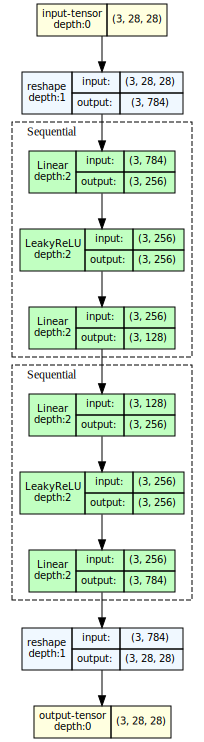

In [11]:
graph = src.utils.model_visualisation.draw_forward_kernel_graph(
    autoencoder,
    input_shape=(3, 28, 28),
    graph_name='Autoencoder',
)
graph.visual_graph


# Task 3: Create the MAE Loss, Optimizer, Scheduler, and Metrics Dictionary

## Goal

Create the training components expected by the shared training loop.

## Components To Create

Implement the following objects:
- `reconstruction_mae(batch)`: return mean absolute error between `batch['signals']['reconstruction']` and `batch['data']['image']`;
- `losses`: a dictionary mapping `'mae'` to `reconstruction_mae`;
- `metrics`: an empty dictionary, because this task has no classification metric;
- `optimizer`: `torch.optim.AdamW(autoencoder.parameters(), lr=1.0e-3)`;
- `scheduler`: `torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer)`.

The training loop accepts a loss dictionary so that progress bars, history, and MLflow can report named losses consistently across tasks.

In [12]:
def reconstruction_mae(batch):
    recon = batch['signals']['reconstruction']
    original = batch['data']['image']
    return torch.abs(recon - original).mean()

losses = {'mae': reconstruction_mae}
metrics = {}
optimizer = torch.optim.AdamW(autoencoder.parameters(), lr=1.0e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer)

## YOUR CODE HERE

with torch.no_grad():
    loss_check_batch = {
        'data': {'image': torch.randn(4, 28, 28)},
    }
    autoencoder(loss_check_batch)
    test_loss_val = {name: fn(loss_check_batch) for name, fn in losses.items()}

answer['loss_names'] = list(losses.keys())
answer['metric_names'] = list(metrics.keys())
answer['optimizer_class'] = optimizer.__class__.__name__
answer['optimizer_defaults'] = dict(optimizer.defaults)
answer['scheduler_class'] = scheduler.__class__.__name__
answer['test_loss_val'] = test_loss_val
pprint(test_loss_val)


{'mae': tensor 0.908}


# Task 4: Create DataLoaders

## Goal

Create dataloaders for the training loop.

## Implementation Details

Use `torch.utils.data.DataLoader` with:
- `batch_size = 64`;
- `shuffle=True` and `drop_last=True` for the training dataloader;
- `shuffle=False` for the validation dataloader.

The dataloaders should be named `train_dl` and `valid_dl`.

In [13]:
batch_size = 64
train_dl = torch.utils.data.DataLoader(MNIST_train, batch_size=batch_size, drop_last=True, shuffle=True)
valid_dl = torch.utils.data.DataLoader(MNIST_valid, batch_size=batch_size, shuffle=False)
## YOUR CODE HERE

train_batch = next(iter(train_dl))
valid_batch = next(iter(valid_dl))

pprint(train_batch)
pprint(valid_batch)

answer['train_batch'] = str(train_batch)
answer['valid_batch'] = str(valid_batch)


{'image': tensor[64, 28, 28] n=50176 (0.2Mb) x∈[-1.000, 1.000] μ=-0.731 σ=0.627,
 'label': tensor[64] i64 x∈[0, 9] μ=4.188 σ=3.116}
{'image': tensor[64, 28, 28] n=50176 (0.2Mb) x∈[-1.000, 1.000] μ=-0.771 σ=0.578,
 'label': tensor[64] i64 x∈[0, 9] μ=4.109 σ=2.795}


# Task 5: Train with the Shared Training Loop

## Goal

Reuse `src.train_loop.train_model`, the same training loop from the shallow feedforward chapter.

## What The Loop Will Do

For each training batch, the loop will:
- wrap the dataloader batch as `{'data': batch}`;
- call `autoencoder(batch)`;
- compute each function in `losses`;
- sum the named losses for backpropagation;
- update the optimizer;
- report batch and epoch losses in the progress bars;
- log losses to MLflow.

For each validation batch, it will run the same model and loss computation without backpropagation.

You do not write a new autoencoder training loop in this notebook. The point of this task is to make the model and losses follow the shared contract.

/usr/local/lib/python3.11/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/06/28 00:11:55 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$G

[Open MLflow run with graphs](http://127.0.0.1:5000/#/experiments/853083639859914893/runs/6979b84e24164b27a7dcbcd566d2bba7)

epochs:   0%|          | 0/3 [00:00<?, ?it/s]

batches:   0%|          | 0/937 [00:00<?, ?it/s]

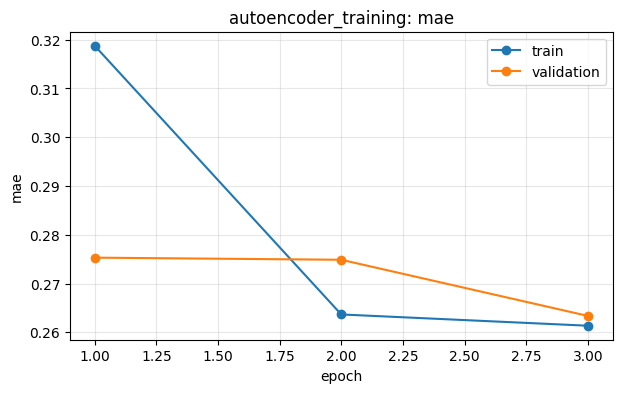

In [14]:
n_epochs = 3

training_logger = src.utils.mlflow.prepare_mlflow_logger('autoencoder_training')

training_history = src.train_loop.train_model(
    autoencoder,
    n_epochs,
    train_dl,
    valid_dl,
    losses,
    optimizer,
    metrics=metrics,
    scheduler=scheduler,
    mlflow_logger=training_logger,
    run_name='autoencoder_training',
)

train_mae_history = training_history['train_loss']['mae']
valid_mae_history = training_history['valid_loss']['mae']

training_logger.end()

answer['train_mae_history'] = train_mae_history
answer['valid_mae_history'] = valid_mae_history


# Reconstruction Check

After training, compare original images with their reconstructions. Perfect reconstructions are not expected after a short checker-friendly run, but the output should have the same shape and should begin to resemble the input.

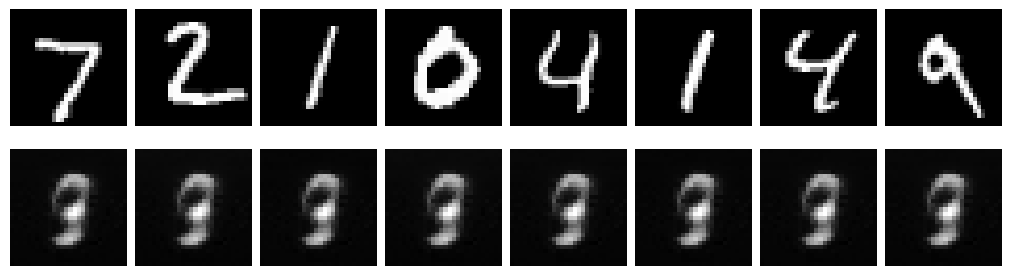

'{"seed_check": {"python.random": [0.8444218515250481, 0.7579544029403025, 0.420571580830845, 0.25891675029296335], "numpy.random.rand": {"__ndarray__": [[0.5488135039273248, 0.7151893663724195, 0.6027633760716439], [0.5448831829968969, 0.4236547993389047, 0.6458941130666561]], "dtype": "float64", "shape": [2, 3], "Corder": true}, "torch.rand": {"__ndarray__": [[0.49625658988952637, 0.7682217955589294, 0.08847743272781372], [0.13203048706054688, 0.30742281675338745, 0.6340786814689636]], "dtype": "float32", "shape": [2, 3], "Corder": true}, "torch.backends.cudnn.deterministic": true}, "X_train.dtype": "torch.float32", "X_valid.dtype": "torch.float32", "y_train.dtype": "torch.int64", "y_valid.dtype": "torch.int64", "X_train.shape": [28, 28], "X_valid.shape": [28, 28], "y_train.shape": [], "y_valid.shape": [], "X_train.mean": -0.7246397137641907, "X_valid.mean": -0.815386176109314, "check_batch": {"data": {"image": {"__ndarray__": [[[-0.4615684747695923, -1.6184245347976685, 1.6378370523

In [15]:
with torch.no_grad():
    visualization_batch = {'data': {'image': valid_batch['image'][:8]}}
    autoencoder.eval()
    autoencoder(visualization_batch)
    original_images = visualization_batch['data']['image']
    reconstructed_images = visualization_batch['signals']['reconstruction']

fig, axes = plt.subplots(2, 8, figsize=(10, 2.8), constrained_layout=True)
for index in range(8):
    axes[0, index].imshow(original_images[index], cmap='gray')
    axes[0, index].axis('off')
    axes[1, index].imshow(reconstructed_images[index], cmap='gray')
    axes[1, index].axis('off')
axes[0, 0].set_ylabel('original')
axes[1, 0].set_ylabel('recon')
plt.show()

answer['reconstruction_shape'] = list(reconstructed_images.shape)
answer['reconstruction_mae_after_training'] = float(
    torch.nn.functional.l1_loss(reconstructed_images, original_images)
)

json_tricks.dump(utils.torch_to_numpy(answer), '.answer.json')


# Task 6: Experiment Time

The checker uses the short training run above. After that works, try longer experiments.

Ideas:
- increase dimentionality of embedding and observe the effects
- check different interfaces in the end of the network (linear function/sigmoid)
- check different loss functions (MSE/MAE)

It is well known effect that MSE images are blurry.

The practical question is whether the model merely copies pixels or learns a useful compressed representation of digit shapes.

In [1]:
# # Optional long-run area. Do not include this in checker-facing answers.

# long_autoencoder = src.models.feedforward.autoencoder.Autoencoder(
#     [28 * 28, 256, 128],
#     activation=torch.nn.LeakyReLU,
# )
# long_optimizer = torch.optim.AdamW(long_autoencoder.parameters(), lr=1.0e-3)
# long_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(long_optimizer)
# long_logger = src.utils.mlflow.prepare_mlflow_logger('autoencoder_long_run')
# long_history = src.train_loop.train_model(
#     long_autoencoder,
#     50,
#     train_dl,
#     valid_dl,
#     losses,
#     long_optimizer,
#     metrics=metrics,
#     scheduler=long_scheduler,
#     mlflow_logger=long_logger,
#     run_name='autoencoder_long_run',
# )
# long_logger.end()


In [2]:
# with torch.no_grad():
#     visualization_batch = {'data': {'image': valid_batch['image'][:8]}}
#     long_autoencoder.eval()
#     long_autoencoder(visualization_batch)
#     original_images = visualization_batch['data']['image']
#     reconstructed_images = visualization_batch['signals']['reconstruction']

# fig, axes = plt.subplots(2, 8, figsize=(10, 2.8), constrained_layout=True)
# for index in range(8):
#     axes[0, index].imshow(original_images[index], cmap='gray')
#     axes[0, index].axis('off')
#     axes[1, index].imshow(reconstructed_images[index], cmap='gray')
#     axes[1, index].axis('off')
# axes[0, 0].set_ylabel('original')
# axes[1, 0].set_ylabel('recon')
# plt.show()

# answer['reconstruction_shape'] = list(reconstructed_images.shape)
# answer['reconstruction_mae_after_training'] = float(
#     torch.nn.functional.l1_loss(reconstructed_images, original_images)
# )



# Embedding Interpolation

A useful way to inspect an autoencoder is to encode two different digits, linearly interpolate between their embeddings, and decode every intermediate embedding back into image space. If the latent space is meaningful, the decoded images should change smoothly rather than jumping randomly.


In [3]:
# interpolation_model = globals().get('long_autoencoder', autoencoder)
# interpolation_model.eval()
# interpolation_device = next(interpolation_model.parameters()).device

# first_index = 0
# first_label = int(MNIST_valid[first_index]['label'])
# second_index = next(
#     index
#     for index in range(1, len(MNIST_valid))
#     if int(MNIST_valid[index]['label']) != first_label
# )
# second_label = int(MNIST_valid[second_index]['label'])

# first_image = MNIST_valid[first_index]['image']
# second_image = MNIST_valid[second_index]['image']
# endpoint_images = torch.stack([first_image, second_image]).to(interpolation_device)
# alphas = torch.linspace(
#     0,
#     1,
#     11,
#     dtype=endpoint_images.dtype,
#     device=interpolation_device,
# ).unsqueeze(1)

# with torch.no_grad():
#     embeddings = interpolation_model.encoder(endpoint_images.reshape(endpoint_images.shape[0], -1))
#     interpolated_embeddings = (1 - alphas) * embeddings[:1] + alphas * embeddings[1:]
#     decoded_images = interpolation_model.decoder(interpolated_embeddings).reshape(-1, 28, 28)

# decoded_images = decoded_images.detach().cpu()

# fig, axes = plt.subplots(1, len(decoded_images), figsize=(12, 1.8), constrained_layout=True)
# for index, ax in enumerate(axes):
#     ax.imshow(decoded_images[index], cmap='gray', vmin=-1, vmax=1)
#     ax.set_title(f'{float(alphas[index].cpu()):.1f}', fontsize=9)
#     ax.set_xticks([])
#     ax.set_yticks([])
# axes[0].set_title(f'{first_label}\n0.0', fontsize=9)
# axes[-1].set_title(f'{second_label}\n1.0', fontsize=9)
# fig.suptitle(f'latent interpolation: {first_label} to {second_label}')
# plt.show()


# Stem Filter Visualization

The first linear layer of the encoder plays the role of a stem: each hidden unit looks at all input pixels through one learned weight vector. Reshaping those vectors back to `28 x 28` lets us inspect which pixel patterns the first layer responds to.


In [4]:
# filter_model = globals().get('long_autoencoder', autoencoder)
# first_linear_layer = next(
#     layer
#     for layer in filter_model.encoder
#     if isinstance(layer, torch.nn.Linear)
# )

# stem_weights = first_linear_layer.weight.detach().cpu()
# filter_count = min(32, stem_weights.shape[0])
# filter_indices = torch.topk(stem_weights.norm(dim=1), filter_count).indices
# stem_filters = stem_weights[filter_indices].reshape(filter_count, 28, 28)
# filter_absmax = stem_filters.abs().amax(dim=(1, 2), keepdim=True).clamp_min(1e-6)
# stem_filters = stem_filters / filter_absmax

# n_cols = 8
# n_rows = int(np.ceil(filter_count / n_cols))
# fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 1.35 * n_rows), constrained_layout=True)
# axes = np.array(axes).reshape(n_rows, n_cols)

# for flat_index, ax in enumerate(axes.flat):
#     ax.set_xticks([])
#     ax.set_yticks([])
#     if flat_index < filter_count:
#         ax.imshow(stem_filters[flat_index], cmap='grey', vmin=-1, vmax=1)
#         ax.set_title(str(int(filter_indices[flat_index])), fontsize=8)
#     else:
#         ax.axis('off')

# fig.suptitle('encoder stem filters')
# plt.show()
